## Building LeNet

- LeNet original model.

In [24]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms

torch.use_deterministic_algorithms(True)

In [25]:
class LeNet(nn.Module):
    def __init__(self):
        super(LeNet, self).__init__()
        self.cn1 = nn.Conv2d(3, 6, 5)
        self.cn2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)
        
    def forward(self, x):
        x = F.relu(self.cn1(x))
        x = F.max_pool2d(x, (2,2))
        x = F.relu(self.cn2(x))
        x = F.max_pool2d(x, (2,2))
        # x = x.view(-1, self.flattened_features(x))
        x = x.flatten(start_dim=1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x
    
    # def flattened_features(self, x):
    #     size = x.size()[1:]
    #     num_feats = 1
    #     for s in size:
    #         num_feats *= s
    #     return num_feats
        
lenet = LeNet()
print(lenet)

LeNet(
  (cn1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (cn2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)


In [ ]:
def train(net, train_loader, optim, epoch):
    # initialize loss
    loss_total = 0.0
    
    for i, data in enumerate(train_loader, 0):
        input, ground_truth = data
        
        # zero the parameter gradients
        optim.zero_grad()
        
        # forward pass, backward pass, optimization step
        output = net(input)
        loss = nn.CrossEntropyLoss()(output, ground_truth)
        loss.backward()
        optim.step()
        
        # update the loss
        loss_total += loss.item()
        
        # print loss statistics
        if(i + 1) % 1000 == 0:
            print('[Epoch number : %d, Mini-batches: %5d] loss: %.3f' %
                  (epoch + 1,
                   i + 1, 
                   loss_total / 200
                   )
                )
            loss_total = 0.0

In [27]:
def test(net, test_loader):
    success = 0
    counter = 0
    
    with torch.no_grad():
        for data in test_loader:
            im, ground_truth = data
            op = net(im)
            _, pred = torch.max(op.data, 1)
            counter += ground_truth.size(0)
            success += (pred == ground_truth).sum().item()
            
            
    print('LeNet accuracy on 10000 images from test dataset: %d %%' %(
        100 * success/counter
    ))

In [28]:
#Trainset
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, 4),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=8, shuffle=True)


# Testset
test_transform = transforms.Compose([
    transforms.ToTensor(), 
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=10000, shuffle=False)

# ordering is important
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

Files already downloaded and verified
Files already downloaded and verified


## Displaying some sample images from trainloader

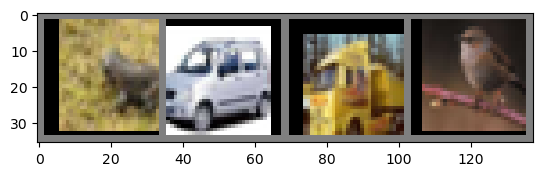

  frog || car || truck || bird


In [29]:
def imageshow(image):
    image = image/2 + 0.5
    npimage = image.numpy()
    plt.imshow(np.transpose(npimage, (1,2,0)))
    plt.show()
    
dataiter = iter(trainloader)
images, labels = next(dataiter)

num_images = 4
imageshow(torchvision.utils.make_grid(images[:num_images]))
print('  '+' || '.join(classes[labels[j]] for j in range(num_images)))

    
    

## Training

In [30]:
optim = torch.optim.Adam(lenet.parameters(), lr=0.001)

for epoch in range(50):
    train(lenet, trainloader, optim, epoch)
    print()
    test(lenet, testloader)
    print()

[Epoch number : 1, Mini-batches:  1000] loss: 9.942
[Epoch number : 1, Mini-batches:  2000] loss: 8.813
[Epoch number : 1, Mini-batches:  3000] loss: 8.390
[Epoch number : 1, Mini-batches:  4000] loss: 8.143
[Epoch number : 1, Mini-batches:  5000] loss: 7.963
[Epoch number : 1, Mini-batches:  6000] loss: 7.777

LeNet accuracy on 10000 images from test dataset: 48 %

[Epoch number : 2, Mini-batches:  1000] loss: 7.547
[Epoch number : 2, Mini-batches:  2000] loss: 7.443
[Epoch number : 2, Mini-batches:  3000] loss: 7.295
[Epoch number : 2, Mini-batches:  4000] loss: 7.238
[Epoch number : 2, Mini-batches:  5000] loss: 7.192
[Epoch number : 2, Mini-batches:  6000] loss: 7.060

LeNet accuracy on 10000 images from test dataset: 54 %

[Epoch number : 3, Mini-batches:  1000] loss: 6.850
[Epoch number : 3, Mini-batches:  2000] loss: 6.827
[Epoch number : 3, Mini-batches:  3000] loss: 6.788
[Epoch number : 3, Mini-batches:  4000] loss: 6.700
[Epoch number : 3, Mini-batches:  5000] loss: 6.680
[E

## Saving Model

In [38]:
model_path = './cifar_model.pth'
torch.save(lenet.state_dict(), model_path)

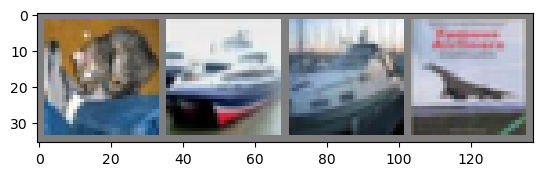

Label:            cat  ship  ship plane
prediction:    cat  ship  ship plane


In [40]:
d_iter = iter(testloader)
im, ground_truth = next(d_iter)

imageshow(torchvision.utils.make_grid(im[:4]))
print('Label:         ',' '.join('%5s' % classes[ground_truth[j]] for j in range(4)))


# load model
lenet_cached = LeNet()
lenet_cached.load_state_dict(torch.load(model_path, weights_only=True))

# model inference
op = lenet_cached(im)

# print predictions
_, pred = torch.max(op, 1)


print('prediction: ', ' '.join('%5s' % classes[pred[j]] for j in range(4)))